In [1]:
!pip install nltk

In [2]:
import pandas as pd
import numpy as np
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!unzip archive.zip

Archive:  archive.zip
  inflating: Fake.csv                
  inflating: True.csv                


In [6]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 0
true["label"] = 1

data = pd.concat([fake, true])

data = data.sample(frac=1, random_state=42)

data.head()

,title,text,subject,date,label
22216,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
4436,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
1526,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
1377,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
8995,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [7]:
print(data.shape)

data.head()

(44898, 5)


,title,text,subject,date,label
22216,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
4436,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
1526,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
1377,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
8995,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [8]:
stemmer = PorterStemmer()

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'https?://\S+','',text)

    text = re.sub(r'<.*?>','',text)

    text = re.sub(r'[^a-zA-Z]',' ',text)

    words = text.split()

    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

Accuracy: 0.9858574610244989

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



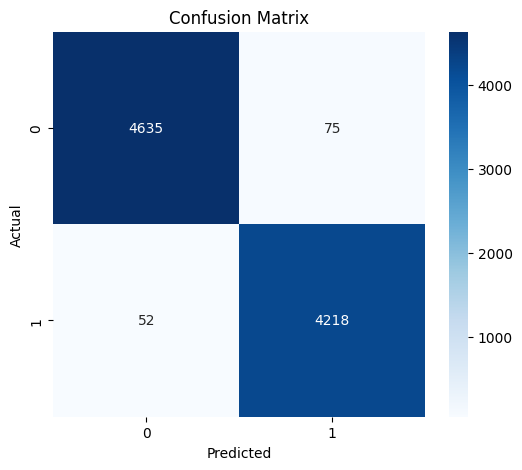

In [10]:
# Create content column
data["content"] = data["title"] + " " + data["text"]

# Clean text
data["content"] = data["content"].apply(clean_text)

# Features and labels
X = data["content"]
y = data["label"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

# Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, pred))

# Confusion Matrix
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
def predict_news(news):
    cleaned = clean_text(news)
    vector = vectorizer.transform([cleaned])

    prediction = model.predict(vector)[0]
    probability = model.predict_proba(vector)[0]

    if prediction == 1:
        print("🟢 Real News")
        print(f"Confidence: {probability[1]*100:.2f}%")
    else:
        print("🔴 Fake News")
        print(f"Confidence: {probability[0]*100:.2f}%")

In [17]:
predict_news("NASA launched a new satellite into space.")

🔴 Fake News
Confidence: 73.00%


In [18]:
predict_news("Aliens landed in New York yesterday.")

🔴 Fake News
Confidence: 84.52%


In [19]:
predict_news("President Donald Trump met with lawmakers in Washington to discuss tax reform.")

🟢 Real News
Confidence: 94.72%
